## 01. ANOVA One Way, comparando com 3 grupos ou mais

In [3]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

In [9]:
df = pd.read_csv('../data/trailers_dados_aulas_1_e_2.csv')
df['tempo_visualizacao'] = df['tempo_visualizacao'].astype(int)
display(df.head())

,trailer_tipo,tempo_visualizacao
0,Drama,104
1,Drama,92
2,Drama,107
3,Drama,125
4,Drama,90


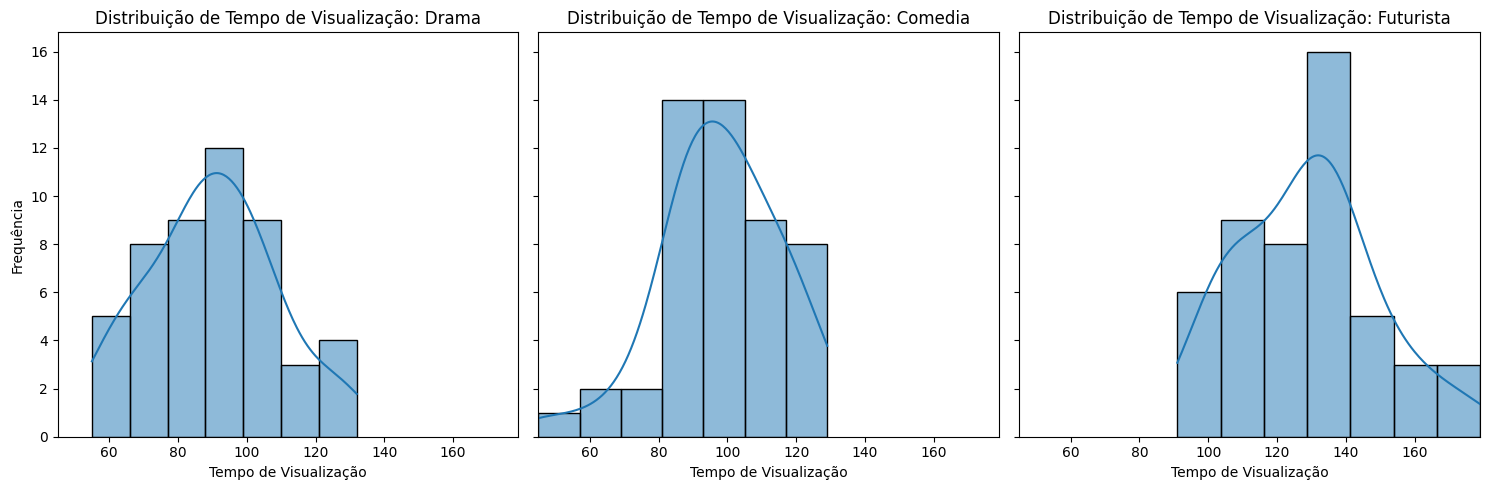

In [12]:
# Analise descritiva
import seaborn as sns
import matplotlib.pyplot as plt


# Mostrar tipos de trailers uncos
trailer_types = df['trailer_tipo'].unique()

# Criar subplots para cada tipo de trailer
fig, axes = plt.subplots(1, len(trailer_types), figsize=(15, 5), sharey=True)

# Plotar a distribuição de tempo de visualização para cada tipo de trailer
for i, trailer_types in enumerate(trailer_types):
    subset_df = df[df['trailer_tipo'] == trailer_types]
    sns.histplot(subset_df['tempo_visualizacao'], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribuição de Tempo de Visualização: {trailer_types}')
    axes[i].set_xlabel('Tempo de Visualização')
    axes[i].set_ylabel('Frequência')

# Ajusar todos  y-axes para ter a mesma escala
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, y_max)

# Ajustar todos x-axes para ter a mesma escala
x_min = df['tempo_visualizacao'].min()
x_max = df['tempo_visualizacao'].max()
for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()


In [13]:
# Agrupar por 'trailer_tipo' e calcular a media, desvio padrão e contagem
stats_table = df.groupby('trailer_tipo')['tempo_visualizacao'].agg(['mean', 'std', 'count']).reset_index()

# Renomear colunas para clareza
stats_table.rename(columns={'mean': 'media', 'std': 'desvio_padrao', 'count': 'numero_observacoes'}, inplace=True)

# Exibir a tabela resultante
display(stats_table)

,trailer_tipo,media,desvio_padrao,numero_observacoes
0,Comedia,97.90,17.521124,50
1,Drama,89.90,18.755407,50
2,Futurista,128.68,20.366479,50



Até aqui exploramos visualmente a distribuição do tempo de visualização por tipo de trailer e calculamos as estatísticas descritivas (média, desvio padrão e tamanho da amostra) para cada grupo, estamos prontos para realizar os cálculos necessários para a **Análise de Variância (ANOVA) One-Way**.

Nos próximos passos, vamos organizar os dados de forma adequada para o teste e, em seguida, executaremos a análise para determinar se há diferenças estatisticamente significativas nas médias de visualização entre os grupos de trailers.

### Estatística F e Distribuição F

A **Estatística F** é a razão entre a variância entre os grupos (MS_between) e a variância dentro dos grupos (MS_within). Ela é calculada usando a seguinte fórmula:

$$ F = \frac{MS_{between}}{MS_{within}} $$

Onde:
*   $ MS_{between} $: Quadrados Médios Entre Grupos
*   $ MS_{within} $: Quadrados Médios Dentro dos Grupos

Se a hipótese nula (de que as médias dos grupos são iguais) for verdadeira, a estatística F calculada seguirá uma **Distribuição F** com $df_{between}$ e $df_{within}$ graus de liberdade. Comparamos a estatística F calculada com os valores da distribuição F para determinar o p-valor.

In [14]:
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
# ANOVA
model = smf.ols('tempo_visualizacao ~ C(trailer_tipo)', data=df).fit()
anova_table = anova.anova_lm(model, typ=2)

print(anova_table)

                       sum_sq     df         F        PR(>F)
C(trailer_tipo)  41921.613333    2.0  58.57436  1.958658e-19
Residual         52603.880000  147.0       NaN           NaN



*   A linha **`C(trailer_tipo)`** representa a variação **entre os grupos** (between-group). A soma dos quadrados entre os grupos é `41921.613333`.
*   A linha **`Residual`** representa a variação **dentro dos grupos** (within-group). A soma dos quadrados dentro dos grupos é `52603.880000`.

---

Como o p-valor da ANOVA (1.958658e-19) é muito menor que 0.05, confirmamos que há diferenças estatisticamente significativas entre as médias de tempo de visualização dos grupos de trailers.

---

O código a seguir visualiza a distribuição F teórica esperada sob a hipótese nula e mostra onde a estatística F que você calculou a partir dos seus dados se encaixa nessa distribuição. Se a linha vertical do F calculado estiver na "cauda" direita da distribuição (longe do pico), isso sugere que o seu resultado é improvável de acontecer apenas por acaso, levando a um p-valor pequeno e à rejeição da hipótese nula.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Degrees of freedom from the ANOVA table
df_between = anova_table.loc['C(trailer_tipo)', 'df']
df_within = anova_table.loc['Residual', 'df']

# Define the range of x values for the plot
x = np.linspace(f.ppf(0.001, df_between, df_within),
                f.ppf(0.999, df_between, df_within), 100)
                
# Plot the F-distribution
plt.figure(figsize=(10, 6))
plt.plot(x, f.pdf(x, df_between, df_within),
         'r-', lw=2, alpha=0.6, label=f'df1={int(df_between)}, df2={int(df_within)}')

# Add a vertical line for the calculated F-statistic
f_calculated = anova_table.loc['C(trailer_tipo)','F']
plt.axvline(f_calculated, color='blue', linestyle='dashed', linewidth=2, label=f'F Calculado = {f_calculated:.2f}')

# Add title and labels
plt.title('Distribuição F com Graus de Liberdade do Teste ANOVA')
plt.xlabel('Valor de F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()